# Battery Materials DSS QML

**Presentation notebook**

Goal: build a student-level Decision Support System for lithium-ion battery
material recommendation using Materials Project data, India-focused screening,
XGBoost, and Qiskit Statevector QML comparison.


## Student-Level Project Flow

This project is presented as a DSS first and a QML exploration second.

1. XGBoost is the strong current classical benchmark for structured materials
   data.
2. Logistic Regression is the simple classical baseline.
3. Qiskit Statevector QML is the quantum-future experiment.
4. The final recommendation is made through DSS ranking tables, not through an
   unsupported claim of quantum advantage.

**Why quantum is included**

Battery materials are controlled by atomic and electronic behavior. That
behavior is quantum mechanical. Classical ML is useful today, but future
quantum models may represent material interactions more naturally. This project
therefore uses Qiskit Statevector QML as a safe first step toward quantum-assisted
materials discovery.


In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import f1_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score

project_folder = Path.cwd()
processed_folder = project_folder / "data" / "processed"

def read_project_data(file_name):
    return pd.read_csv(processed_folder / file_name)

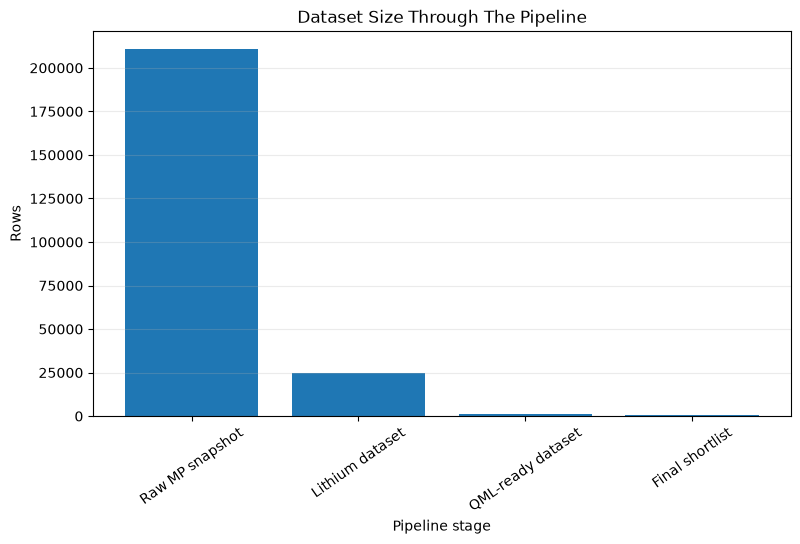

In [2]:
lithium_scored_dataframe = read_project_data("lithium india scored.csv")
qml_ready_dataframe = read_project_data("qml_ready_lithium_india.csv")
final_shortlist_dataframe = read_project_data("final india battery shortlist.csv")

raw_data_folder = project_folder / "data" / "raw" / "materials_project_hf"
raw_materials_project_row_count = 0

for raw_file_path in sorted(raw_data_folder.glob("*.parquet")):
    raw_file_dataframe = pd.read_parquet(raw_file_path)
    raw_materials_project_row_count = raw_materials_project_row_count + len(raw_file_dataframe)

pipeline_counts_dataframe = pd.DataFrame([
    {"stage": "Raw MP snapshot", "rows": raw_materials_project_row_count},
    {"stage": "Lithium dataset", "rows": len(lithium_scored_dataframe)},
    {"stage": "QML-ready dataset", "rows": len(qml_ready_dataframe)},
    {"stage": "Final shortlist", "rows": len(final_shortlist_dataframe)},
])

plt.figure(figsize=(9, 5))
plt.bar(pipeline_counts_dataframe["stage"], pipeline_counts_dataframe["rows"])
plt.title("Dataset Size Through The Pipeline")
plt.xlabel("Pipeline stage")
plt.ylabel("Rows")
plt.xticks(rotation=35)
plt.grid(axis="y", alpha=0.25)
plt.show()


,battery_family,rows
0,Other lithium material,14027
1,LCO-family,3541
2,LMO-family,3394
3,LTO-family,964
4,Li-S or sulfide-family,892
5,Silicon-family,852
6,LFP-family,735
7,Carbon-family,477


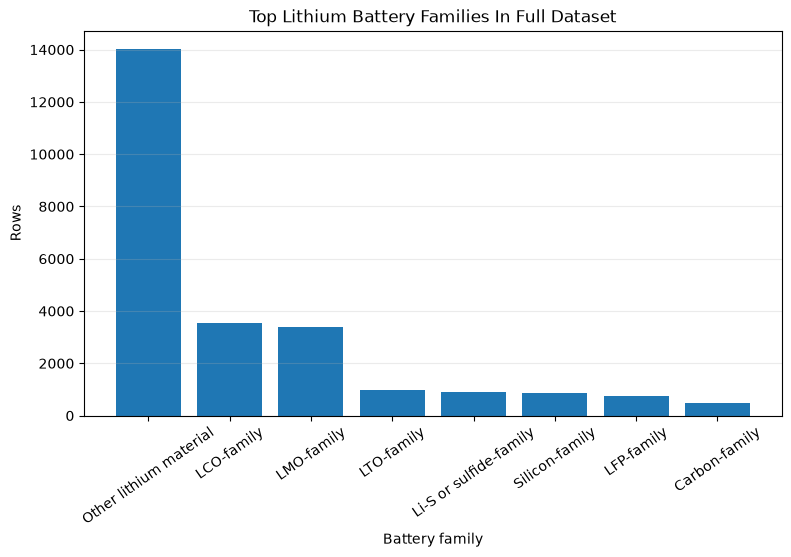

In [3]:
lithium_scored_dataframe = read_project_data("lithium india scored.csv")

family_count_series = lithium_scored_dataframe["battery_family"].value_counts()
top_family_count_series = family_count_series.head(8)
family_counts_dataframe = top_family_count_series.reset_index()
family_counts_dataframe.columns = ["battery_family", "rows"]

display(family_counts_dataframe)

plt.figure(figsize=(9, 5))
plt.bar(family_counts_dataframe["battery_family"], family_counts_dataframe["rows"])
plt.title("Top Lithium Battery Families In Full Dataset")
plt.xlabel("Battery family")
plt.ylabel("Rows")
plt.xticks(rotation=35)
plt.grid(axis="y", alpha=0.25)
plt.show()


,india_decision_label,rows
0,Caution,13524
1,Research Candidate,5883
2,Avoid / Benchmark,4370
3,Recommend,1180


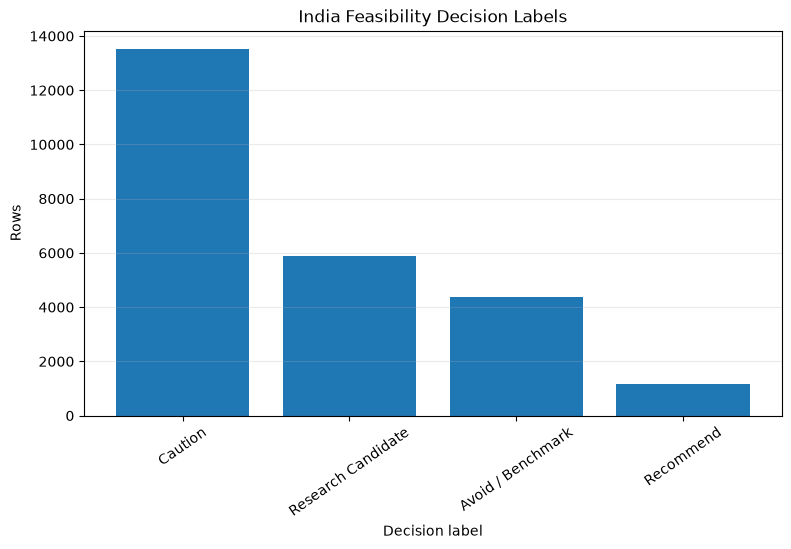

In [4]:
lithium_scored_dataframe = read_project_data("lithium india scored.csv")

decision_count_series = lithium_scored_dataframe["india_decision_label"].value_counts()
decision_counts_dataframe = decision_count_series.reset_index()
decision_counts_dataframe.columns = ["india_decision_label", "rows"]

display(decision_counts_dataframe)

plt.figure(figsize=(9, 5))
plt.bar(decision_counts_dataframe["india_decision_label"], decision_counts_dataframe["rows"])
plt.title("India Feasibility Decision Labels")
plt.xlabel("Decision label")
plt.ylabel("Rows")
plt.xticks(rotation=35)
plt.grid(axis="y", alpha=0.25)
plt.show()


,battery_family,rows
0,LFP-family,464
1,Li-S or sulfide-family,91
2,LMFP-family,48
3,Silicon-family,17
4,Carbon-family,5
5,LMO-family,4


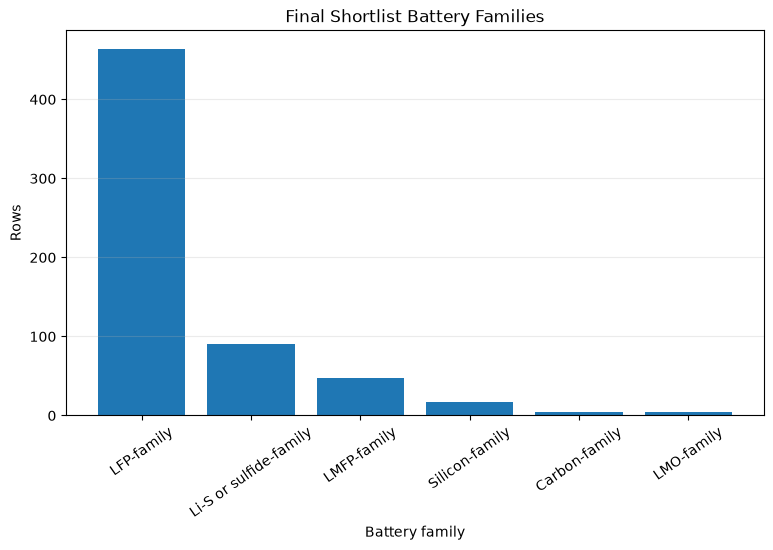

In [5]:
final_shortlist_dataframe = read_project_data("final india battery shortlist.csv")

final_family_count_series = final_shortlist_dataframe["battery_family"].value_counts()
final_family_counts_dataframe = final_family_count_series.reset_index()
final_family_counts_dataframe.columns = ["battery_family", "rows"]

display(final_family_counts_dataframe)

plt.figure(figsize=(9, 5))
plt.bar(final_family_counts_dataframe["battery_family"], final_family_counts_dataframe["rows"])
plt.title("Final Shortlist Battery Families")
plt.xlabel("Battery family")
plt.ylabel("Rows")
plt.xticks(rotation=35)
plt.grid(axis="y", alpha=0.25)
plt.show()


In [6]:
final_shortlist_dataframe = read_project_data("final india battery shortlist.csv")

top_candidate_columns = [
    "material_id",
    "formula",
    "battery_family",
    "india_decision_label",
    "shortlist_rule_type",
    "shortlist_score",
    "predicted_stable_probability",
    "predicted_energy_above_hull_clipped",
    "india_feasibility_score",
]
top_candidates_dataframe = final_shortlist_dataframe[top_candidate_columns].head(10)
display(top_candidates_dataframe)


,material_id,formula,battery_family,india_decision_label,shortlist_rule_type,shortlist_score,predicted_stable_probability,predicted_energy_above_hull_clipped,india_feasibility_score
0,mp-19430,Li3Fe2(PO4)3,LFP-family,Recommend,Benchmark family exception,59.52,0.167670,0.011649,98
1,mp-554093,Li9Fe3P8O29,LFP-family,Recommend,Benchmark family exception,59.10,0.147220,0.009104,98
2,mp-1195117,LiFeP2(HO3)2,LFP-family,Recommend,Benchmark family exception,57.42,0.172900,0.016302,94
3,mp-19294,LiFeP2O7,LFP-family,Recommend,Benchmark family exception,57.26,0.222164,0.038672,100
4,mp-19017,LiFePO4,LFP-family,Recommend,Benchmark family exception,56.48,0.138139,0.023703,100
5,mp-26985,Li2Fe3(P2O7)2,LFP-family,Recommend,Benchmark family exception,56.39,0.115441,0.015525,98
6,mp-1198378,NaLiFePO4F,LFP-family,Recommend,Benchmark family exception,56.22,0.167278,0.021042,94
7,mp-6373,Li3Fe2(PO4)3,LFP-family,Recommend,Benchmark family exception,55.50,0.131681,0.023631,98
8,mp-25993,Li3Fe2(PO4)3,LFP-family,Recommend,Benchmark family exception,55.32,0.126405,0.023346,98
9,mp-504179,LiFe(PO3)3,LFP-family,Recommend,Benchmark family exception,54.88,0.132133,0.026851,98


## DSS Compound Recommendation Ranking

The project is used as a Decision Support System here. The main output is a
ranked list of exact lithium compound formulas. Battery family is shown only as
supporting context.

In this flow, QML gives the first stability signal. XGBoost is used as a
corrective backup when the QML probability is uncertain or when both models
disagree. This keeps the DSS quantum-led without ignoring the stronger
classical benchmark.


In [7]:
dss_compound_ranking_dataframe = read_project_data("dss compound recommendation ranking.csv")
dss_family_ranking_dataframe = read_project_data("dss battery family recommendation ranking.csv")

display(dss_compound_ranking_dataframe.head(10))
display(dss_family_ranking_dataframe.head(10))


,dss_rank,formula,material_id,battery_family,dss_decision,hybrid_recommendation_score,hybrid_stable_probability,qml_stable_probability,xgboost_stable_probability,qml_weight,...,hybrid_decision_role,model_disagreement,qml_probability_std,shortlist_score,india_feasibility_score,predicted_energy_above_hull_clipped,band_gap,is_stable,shortlist_rule_type,short_conceptual_reason
0,1,SrLi2SiO4,mp-1191141,Silicon-family,R&D anode improvement option,88.4614,0.840086,0.850240,0.825156,0.5952,...,QML-led; XGBoost agrees,False,0.040830,87.58,87,0.000000,4.6041,True,Strict model shortlist,High-potential anode direction; better for ble...
1,2,Li2MnGeS4,mp-3268644,Li-S or sulfide-family,Long-term R&D option,87.7711,0.869024,0.845355,0.903325,0.5917,...,QML-led; XGBoost agrees,False,0.029080,88.83,81,0.000864,1.9728,True,Strict model shortlist,"High-potential chemistry, but less direct for ..."
2,3,LiGaSiO4,mp-18147,Silicon-family,R&D anode improvement option,87.5648,0.832934,0.851560,0.805444,0.5961,...,QML-led; XGBoost agrees,False,0.039106,86.22,87,0.002373,4.2293,True,Strict model shortlist,High-potential anode direction; better for ble...
3,4,SrLi2SnS4,mp-3210567,Li-S or sulfide-family,Long-term R&D option,87.2897,0.878242,0.867058,0.895510,0.6069,...,QML-led; XGBoost agrees,False,0.018826,87.60,78,0.000000,3.0972,True,Strict model shortlist,"High-potential chemistry, but less direct for ..."
4,5,Rb2Li2SnS4,mp-3205208,Li-S or sulfide-family,Long-term R&D option,87.2338,0.875871,0.856974,0.904204,0.5999,...,QML-led; XGBoost agrees,False,0.038511,87.99,78,0.000000,3.0399,True,Strict model shortlist,"High-potential chemistry, but less direct for ..."
5,6,Cs2Li2SnS4,mp-3209528,Li-S or sulfide-family,Long-term R&D option,87.2229,0.875547,0.856069,0.904665,0.5992,...,QML-led; XGBoost agrees,False,0.039244,88.01,78,0.000000,3.2409,True,Strict model shortlist,"High-potential chemistry, but less direct for ..."
6,7,BaLi2SnS4,mp-3211122,Li-S or sulfide-family,Long-term R&D option,87.1726,0.875966,0.867018,0.889782,0.6069,...,QML-led; XGBoost agrees,False,0.018827,87.34,78,0.000000,3.0828,True,Strict model shortlist,"High-potential chemistry, but less direct for ..."
7,8,Li2ZnGeS4,mp-1210804,Li-S or sulfide-family,Long-term R&D option,86.7156,0.863866,0.841678,0.895690,0.5892,...,QML-led; XGBoost agrees,False,0.030944,87.61,78,0.000000,2.1846,True,Strict model shortlist,"High-potential chemistry, but less direct for ..."
8,9,Rb2Li2TiS4,mp-3215312,Li-S or sulfide-family,Long-term R&D option,86.5100,0.850350,0.869032,0.821337,0.6083,...,QML-led; XGBoost agrees,False,0.027653,84.96,80,0.000000,2.6367,True,Strict model shortlist,"High-potential chemistry, but less direct for ..."
9,10,K2Li2TiS4,mp-3205916,Li-S or sulfide-family,Long-term R&D option,86.5069,0.850347,0.869416,0.820697,0.6086,...,QML-led; XGBoost agrees,False,0.027436,84.93,80,0.000000,2.5669,True,Strict model shortlist,"High-potential chemistry, but less direct for ..."


,dss_rank,dss_family_rank,battery_family,dss_decision,shortlist_rows,average_hybrid_recommendation_score,average_hybrid_stable_probability,average_qml_stable_probability,average_xgboost_stable_probability,average_shortlist_score,average_india_feasibility_score,average_predicted_stable_probability,median_predicted_energy_above_hull,top_material_id,top_formula,short_reason
0,1,5,Silicon-family,R&D anode improvement option,17,83.1598,0.8004,0.8436,0.7376,80.6224,87.0000,0.7376,0.0151,mp-1191141,SrLi2SiO4,High-potential anode direction; better for ble...
1,2,6,Li-S or sulfide-family,Long-term R&D option,91,81.8845,0.8022,0.8037,0.7928,81.3991,78.0220,0.7928,0.0034,mp-3268644,Li2MnGeS4,"High-potential chemistry, but less direct for ..."
2,3,3,LMO-family,Selective low-cost option,4,77.7259,0.7567,0.8153,0.6783,74.9500,89.2500,0.6783,0.0288,mp-581301,Li2MgMn3O8,Manganese-based family; useful when cost matte...
3,4,4,Carbon-family,Useful anode/support material,5,70.6460,0.7201,0.7128,0.7261,72.9580,94.8000,0.7261,0.0647,mp-3247282,LiEr4MnC8,"Practical supporting material, but not a compl..."
4,5,1,LFP-family,Best near-term purchase direction,464,48.3322,0.1033,0.1626,0.0148,45.2782,96.0259,0.0148,0.0487,mp-554093,Li9Fe3P8O29,India-friendly iron phosphate chemistry; avoid...
5,6,2,LMFP-family,Good pilot and next-generation option,48,48.1000,0.0894,0.1428,0.0094,45.1400,94.2083,0.0094,0.0398,mp-1221200,Na4Li4MnFe3P4(O4F)4,LFP-like family with manganese; useful for imp...


## Quantum Setup Used

This is explanation for the presentation, not model code.

| Item | Value |
| --- | --- |
| QML method | Qiskit Statevector quantum kernel classifier |
| Qiskit objects | `QuantumCircuit` and `Statevector.from_instruction` |
| Main circuit gates | `RY` rotation gates and `CP` controlled-phase gates |
| Best simple QML tuning | 8 qubits, `pi / 2` angle scale, SVM `C = 1.0` |
| Best final QML section | 4-qubit `entangled_pi` kernel with SVM `C = 5.0` |
| Validation | 4-fold tuning and 10 repeated train/test splits |

The actual Qiskit circuit is shown in the next code cell.


,feature,scaled_value_used_in_example
0,formation_energy_per_atom,0.20
1,has_o,1.00
2,space_group_number,0.53
3,theoretical,1.00


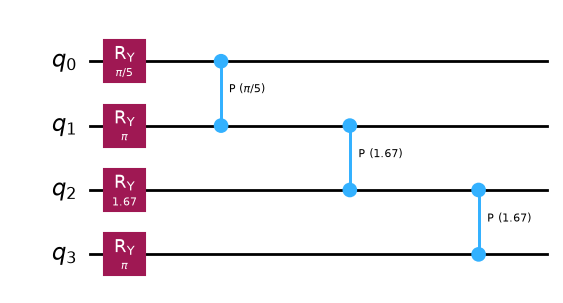

,statevector_length
0,16


In [8]:
sample_feature_names = [
    "formation_energy_per_atom",
    "has_o",
    "space_group_number",
    "theoretical",
]

sample_feature_values = [0.20, 1.00, 0.53, 1.00]

qiskit_example_dataframe = pd.DataFrame(
    {
        "feature": sample_feature_names,
        "scaled_value_used_in_example": sample_feature_values,
    }
)
display(qiskit_example_dataframe)

angle_scale_value = 3.141592653589793
entanglement_strength = 3.141592653589793

qiskit_circuit = QuantumCircuit(4)

for feature_index in range(4):
    feature_value = sample_feature_values[feature_index]
    angle = angle_scale_value * feature_value
    qiskit_circuit.ry(angle, feature_index)

for feature_index in range(3):
    first_value = sample_feature_values[feature_index]
    second_value = sample_feature_values[feature_index + 1]
    phase_angle = entanglement_strength * first_value * second_value
    qiskit_circuit.cp(phase_angle, feature_index, feature_index + 1)

qiskit_circuit_diagram = qiskit_circuit.draw(output="mpl")
display(qiskit_circuit_diagram)

qiskit_statevector = Statevector.from_instruction(qiskit_circuit)
statevector_summary_dataframe = pd.DataFrame([
    {"statevector_length": len(qiskit_statevector.data)}
])
display(statevector_summary_dataframe)


## Exhaustive QML Feature-Combination Tuning

This step tests the stronger tuning approach: all selected feature-count
combinations are compared with all angle scales and all SVM `C` values. The
full result table has 8,388 rows.


In [9]:
qml_exhaustive_results_dataframe = read_project_data("qml exhaustive feature combination results.csv")
qml_exhaustive_top_results_dataframe = read_project_data("qml exhaustive feature combination top results.csv")
qml_exhaustive_best_result = qml_exhaustive_top_results_dataframe.iloc[0]

qml_exhaustive_summary_dataframe = pd.DataFrame([
    {
        "total_configurations": len(qml_exhaustive_results_dataframe),
        "feature_combinations": 466,
        "feature_count": int(qml_exhaustive_best_result["feature_count"]),
        "angle_scale": qml_exhaustive_best_result["angle_scale"],
        "svm_c": qml_exhaustive_best_result["c_value"],
        "cv_accuracy": qml_exhaustive_best_result["cv_accuracy"],
        "cv_stable_f1": qml_exhaustive_best_result["cv_stable_f1"],
    }
])
display(qml_exhaustive_summary_dataframe)

qml_exhaustive_top_display_dataframe = qml_exhaustive_top_results_dataframe[
    [
        "feature_count",
        "feature_names",
        "angle_scale",
        "c_value",
        "cv_accuracy",
        "cv_stable_recall",
        "cv_stable_f1",
    ]
].head(10)
display(qml_exhaustive_top_display_dataframe)


,total_configurations,feature_combinations,feature_count,angle_scale,svm_c,cv_accuracy,cv_stable_f1
0,8388,466,8,pi,10.0,0.8138,0.8162


,feature_count,feature_names,angle_scale,c_value,cv_accuracy,cv_stable_recall,cv_stable_f1
0,8,scaled_space_group_number; scaled_band_gap; sc...,pi,10.0,0.8138,0.8300,0.8162
1,8,scaled_space_group_number; scaled_band_gap; sc...,pi_over_2,2.0,0.8050,0.8600,0.8152
2,6,scaled_space_group_number; scaled_band_gap; sc...,pi,10.0,0.8050,0.8600,0.8151
3,6,scaled_space_group_number; scaled_band_gap; sc...,pi,10.0,0.8088,0.8450,0.8150
4,6,scaled_space_group_number; scaled_band_gap; sc...,pi,1.0,0.8050,0.8575,0.8142
5,8,scaled_space_group_number; scaled_band_gap; sc...,pi_over_2,1.0,0.8038,0.8600,0.8142
6,8,scaled_space_group_number; scaled_band_gap; sc...,pi_over_2,10.0,0.8050,0.8500,0.8131
7,8,scaled_space_group_number; scaled_band_gap; sc...,pi_over_2,1.0,0.8038,0.8525,0.8128
8,10,scaled_space_group_number; scaled_band_gap; sc...,pi_over_2,10.0,0.8038,0.8525,0.8126
9,6,scaled_space_group_number; scaled_band_gap; sc...,pi,1.0,0.8025,0.8575,0.8126


,model,accuracy,stable_precision,stable_recall,stable_f1
0,QML quantum kernel,0.8100,0.7870,0.85,0.8173
1,Tuned QML quantum kernel,0.8200,0.7963,0.86,0.8269
2,Improved QML separate section,0.8200,0.8077,0.84,0.8235
3,Improved QML threshold tuning,0.8300,0.8000,0.88,0.8381
4,Improved QML kernel alignment,0.8200,0.7857,0.88,0.8302
5,XGBoost same QML data,0.8300,0.8367,0.82,0.8283
6,XGBoost full project,0.9091,0.7300,0.70,0.7100


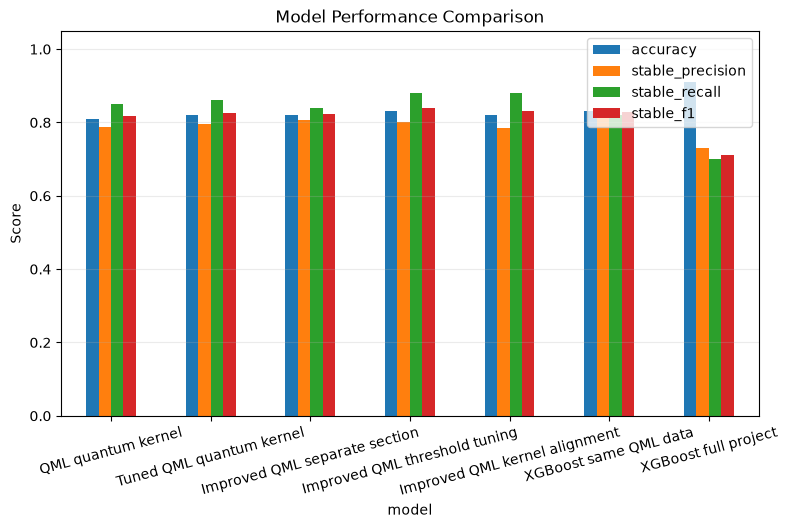

In [10]:
qml_predictions_dataframe = read_project_data("qml baseline predictions.csv")
tuned_qml_predictions_dataframe = read_project_data("qml tuned best predictions.csv")
improved_qml_predictions_dataframe = read_project_data("improved qml best predictions.csv")
improved_qml_threshold_predictions_dataframe = read_project_data("improved qml threshold predictions.csv")
improved_qml_alignment_predictions_dataframe = read_project_data("improved qml alignment predictions.csv")

tuned_true_labels = tuned_qml_predictions_dataframe["target_is_stable"]
tuned_qml_predicted_labels = tuned_qml_predictions_dataframe["tuned_qml_predicted_label"]
improved_true_labels = improved_qml_predictions_dataframe["target_is_stable"]
improved_qml_predicted_labels = improved_qml_predictions_dataframe["improved_qml_predicted_label"]
threshold_true_labels = improved_qml_threshold_predictions_dataframe["target_is_stable"]
threshold_qml_predicted_labels = improved_qml_threshold_predictions_dataframe["threshold_qml_predicted_label"]
alignment_true_labels = improved_qml_alignment_predictions_dataframe["target_is_stable"]
alignment_qml_predicted_labels = improved_qml_alignment_predictions_dataframe["alignment_qml_predicted_label"]

def calculate_model_scores(model_name, true_values, predicted_values):
    return {
        "model": model_name,
        "accuracy": accuracy_score(true_values, predicted_values),
        "stable_precision": precision_score(true_values, predicted_values, zero_division=0),
        "stable_recall": recall_score(true_values, predicted_values, zero_division=0),
        "stable_f1": f1_score(true_values, predicted_values, zero_division=0),
    }

model_score_inputs = [
    ["QML quantum kernel", qml_predictions_dataframe["target_is_stable"], qml_predictions_dataframe["qml_predicted_label"]],
    ["Tuned QML quantum kernel", tuned_qml_predictions_dataframe["target_is_stable"], tuned_qml_predictions_dataframe["tuned_qml_predicted_label"]],
    ["Improved QML separate section", improved_qml_predictions_dataframe["target_is_stable"], improved_qml_predictions_dataframe["improved_qml_predicted_label"]],
    ["Improved QML threshold tuning", improved_qml_threshold_predictions_dataframe["target_is_stable"], improved_qml_threshold_predictions_dataframe["threshold_qml_predicted_label"]],
    ["Improved QML kernel alignment", improved_qml_alignment_predictions_dataframe["target_is_stable"], improved_qml_alignment_predictions_dataframe["alignment_qml_predicted_label"]],
    ["XGBoost same QML data", qml_predictions_dataframe["target_is_stable"], qml_predictions_dataframe["xgboost_same_data_predicted_label"]],
]

metric_rows = []
for model_name, true_values, predicted_values in model_score_inputs:
    metric_rows.append(calculate_model_scores(model_name, true_values, predicted_values))

metric_rows.append({
    "model": "XGBoost full project",
    "accuracy": 0.9091,
    "stable_precision": 0.7300,
    "stable_recall": 0.7000,
    "stable_f1": 0.7100,
})

metric_dataframe = pd.DataFrame(metric_rows).round(4)
display(metric_dataframe)

metric_plot_dataframe = metric_dataframe.set_index("model")
metric_plot_dataframe = metric_plot_dataframe[["accuracy", "stable_precision", "stable_recall", "stable_f1"]]
metric_plot_dataframe.plot(kind="bar", figsize=(9, 5))
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=15)
plt.grid(axis="y", alpha=0.25)
plt.show()



,predicted_unstable,predicted_stable
actual_unstable,78,22
actual_stable,14,86


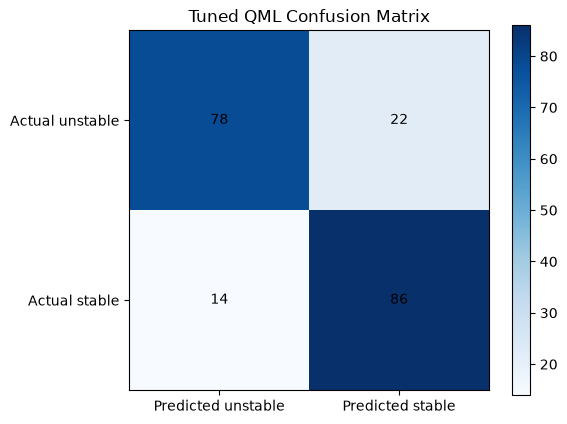

In [11]:
qml_confusion_matrix = confusion_matrix(tuned_true_labels, tuned_qml_predicted_labels, labels=[0, 1])
confusion_dataframe = pd.DataFrame(
    qml_confusion_matrix,
    index=["actual_unstable", "actual_stable"],
    columns=["predicted_unstable", "predicted_stable"],
)
display(confusion_dataframe)

plt.figure(figsize=(5.8, 4.8))
plt.imshow(qml_confusion_matrix, cmap="Blues")
plt.title("Tuned QML Confusion Matrix")
plt.xticks([0, 1], ["Predicted unstable", "Predicted stable"])
plt.yticks([0, 1], ["Actual unstable", "Actual stable"])
for row_index in range(2):
    for column_index in range(2):
        cell_value = qml_confusion_matrix[row_index, column_index]
        plt.text(column_index, row_index, cell_value, ha="center", va="center")
plt.colorbar()
plt.show()

In [12]:
tuned_qml_predictions_dataframe = read_project_data("qml tuned best predictions.csv")

sample_predictions_dataframe = tuned_qml_predictions_dataframe[
    [
        "material_id",
        "formula",
        "target_is_stable",
        "tuned_qml_predicted_label",
        "tuned_qml_stable_probability",
    ]
].head(10)
display(sample_predictions_dataframe)


,material_id,formula,target_is_stable,tuned_qml_predicted_label,tuned_qml_stable_probability
0,mp-861915,LiDy2Ir,1,1,0.807710
1,mp-1191394,Li8Nd7Ge10,0,1,0.646366
2,mp-759724,Li3MnF7,0,0,0.224167
3,mp-37480,LiSbSe2,0,1,0.797986
4,mp-3203193,LiV(CuS2)2,1,1,0.879643
5,mp-3203521,BaSr2(LiSn2)4,1,1,0.648675
6,mp-1212343,Li22(Cu3Si2)7,1,1,0.846576
7,mp-1185354,LiGd2Os,1,1,0.839047
8,mp-776176,Li4Ti3V3(CuO8)2,0,0,0.221253
9,mp-758945,Li5CuHO4,0,1,0.534869


In [13]:
improved_qml_tuning_results_dataframe = read_project_data("improved qml tuning results.csv")
improved_qml_predictions_dataframe = read_project_data("improved qml best predictions.csv")

sorted_improved_results_dataframe = improved_qml_tuning_results_dataframe.sort_values(
    by=["cv_stable_f1", "cv_accuracy", "cv_stable_recall"],
    ascending=[False, False, False],
)
improved_best_result = sorted_improved_results_dataframe.iloc[0]

improved_true_labels = improved_qml_predictions_dataframe["target_is_stable"]
improved_qml_predicted_labels = improved_qml_predictions_dataframe["improved_qml_predicted_label"]

improved_test_accuracy = accuracy_score(improved_true_labels, improved_qml_predicted_labels)
improved_test_f1 = f1_score(improved_true_labels, improved_qml_predicted_labels, zero_division=0)

improved_summary_row = {
    "section": "Improved QML separate section",
    "feature_preparation": "feature importance + PCA",
    "best_kernel": improved_best_result["kernel_name"],
    "best_qubits": int(improved_best_result["pca_component_count"]),
    "angle_scale": improved_best_result["angle_scale"],
    "svm_c": improved_best_result["c_value"],
    "cv_stable_f1": improved_best_result["cv_stable_f1"],
    "test_accuracy": improved_test_accuracy,
    "test_stable_f1": improved_test_f1,
}

improved_summary_dataframe = pd.DataFrame([improved_summary_row])
improved_summary_dataframe = improved_summary_dataframe.round(4)

display(improved_summary_dataframe)


,section,feature_preparation,best_kernel,best_qubits,angle_scale,svm_c,cv_stable_f1,test_accuracy,test_stable_f1
0,Improved QML separate section,feature importance + PCA,entangled_pi,8,pi,1.0,0.8594,0.82,0.8235


,predicted_unstable,predicted_stable
actual_unstable,80,20
actual_stable,16,84


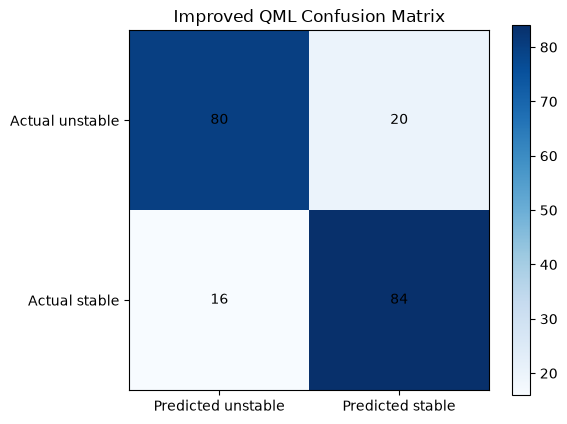

In [14]:
improved_qml_confusion_matrix = confusion_matrix(
    improved_true_labels,
    improved_qml_predicted_labels,
    labels=[0, 1],
)
improved_confusion_dataframe = pd.DataFrame(
    improved_qml_confusion_matrix,
    index=["actual_unstable", "actual_stable"],
    columns=["predicted_unstable", "predicted_stable"],
)
display(improved_confusion_dataframe)

plt.figure(figsize=(5.8, 4.8))
plt.imshow(improved_qml_confusion_matrix, cmap="Blues")
plt.title("Improved QML Confusion Matrix")
plt.xticks([0, 1], ["Predicted unstable", "Predicted stable"])
plt.yticks([0, 1], ["Actual unstable", "Actual stable"])
for row_index in range(2):
    for column_index in range(2):
        cell_value = improved_qml_confusion_matrix[row_index, column_index]
        plt.text(column_index, row_index, cell_value, ha="center", va="center")
plt.colorbar()
plt.show()

In [15]:
improved_qml_predictions_dataframe = read_project_data("improved qml best predictions.csv")

improved_sample_predictions_dataframe = improved_qml_predictions_dataframe[
    [
        "material_id",
        "formula",
        "target_is_stable",
        "improved_qml_predicted_label",
        "improved_qml_stable_probability",
    ]
].head(10)
display(improved_sample_predictions_dataframe)


,material_id,formula,target_is_stable,improved_qml_predicted_label,improved_qml_stable_probability
0,mp-861915,LiDy2Ir,1,1,0.858026
1,mp-1191394,Li8Nd7Ge10,0,1,0.906220
2,mp-759724,Li3MnF7,0,0,0.349595
3,mp-37480,LiSbSe2,0,1,0.867233
4,mp-3203193,LiV(CuS2)2,1,1,0.850826
5,mp-3203521,BaSr2(LiSn2)4,1,1,0.859480
6,mp-1212343,Li22(Cu3Si2)7,1,1,0.866711
7,mp-1185354,LiGd2Os,1,1,0.858079
8,mp-776176,Li4Ti3V3(CuO8)2,0,0,0.120947
9,mp-758945,Li5CuHO4,0,0,0.113101


In [16]:
improved_qml_threshold_results_dataframe = read_project_data("improved qml threshold results.csv")
improved_qml_threshold_predictions_dataframe = read_project_data("improved qml threshold predictions.csv")

sorted_threshold_results_dataframe = improved_qml_threshold_results_dataframe.sort_values(
    by=["cv_stable_f1", "cv_accuracy", "cv_stable_recall"],
    ascending=[False, False, False],
)
improved_best_threshold_result = sorted_threshold_results_dataframe.iloc[0]

threshold_true_labels = improved_qml_threshold_predictions_dataframe["target_is_stable"]
threshold_qml_predicted_labels = improved_qml_threshold_predictions_dataframe["threshold_qml_predicted_label"]

threshold_test_accuracy = accuracy_score(threshold_true_labels, threshold_qml_predicted_labels)
threshold_test_precision = precision_score(threshold_true_labels, threshold_qml_predicted_labels, zero_division=0)
threshold_test_recall = recall_score(threshold_true_labels, threshold_qml_predicted_labels, zero_division=0)
threshold_test_f1 = f1_score(threshold_true_labels, threshold_qml_predicted_labels, zero_division=0)

threshold_summary_row = {
    "section": "Threshold experiment",
    "selected_threshold": improved_best_threshold_result["stable_threshold"],
    "cv_stable_f1": improved_best_threshold_result["cv_stable_f1"],
    "test_accuracy": threshold_test_accuracy,
    "test_stable_precision": threshold_test_precision,
    "test_stable_recall": threshold_test_recall,
    "test_stable_f1": threshold_test_f1,
}

threshold_summary_dataframe = pd.DataFrame([threshold_summary_row])
threshold_summary_dataframe = threshold_summary_dataframe.round(4)

display(threshold_summary_dataframe)


,section,selected_threshold,cv_stable_f1,test_accuracy,test_stable_precision,test_stable_recall,test_stable_f1
0,Threshold experiment,0.3,0.8622,0.83,0.8,0.88,0.8381


,predicted_unstable,predicted_stable
actual_unstable,78,22
actual_stable,12,88


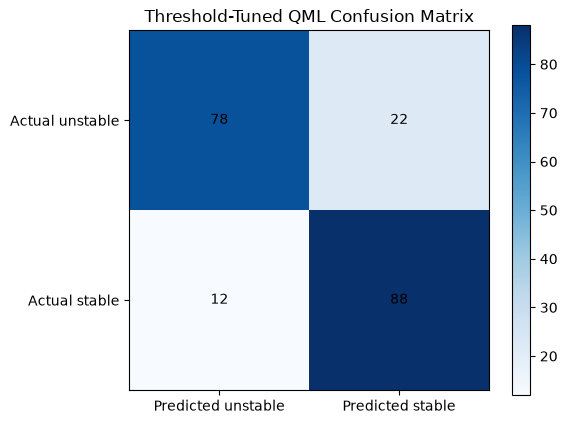

In [17]:
threshold_qml_confusion_matrix = confusion_matrix(
    threshold_true_labels,
    threshold_qml_predicted_labels,
    labels=[0, 1],
)
threshold_confusion_dataframe = pd.DataFrame(
    threshold_qml_confusion_matrix,
    index=["actual_unstable", "actual_stable"],
    columns=["predicted_unstable", "predicted_stable"],
)
display(threshold_confusion_dataframe)

plt.figure(figsize=(5.8, 4.8))
plt.imshow(threshold_qml_confusion_matrix, cmap="Blues")
plt.title("Threshold-Tuned QML Confusion Matrix")
plt.xticks([0, 1], ["Predicted unstable", "Predicted stable"])
plt.yticks([0, 1], ["Actual unstable", "Actual stable"])
for row_index in range(2):
    for column_index in range(2):
        cell_value = threshold_qml_confusion_matrix[row_index, column_index]
        plt.text(column_index, row_index, cell_value, ha="center", va="center")
plt.colorbar()
plt.show()

In [18]:
improved_qml_alignment_results_dataframe = read_project_data("improved qml alignment results.csv")
improved_qml_alignment_predictions_dataframe = read_project_data("improved qml alignment predictions.csv")

sorted_alignment_results_dataframe = improved_qml_alignment_results_dataframe.sort_values(
    by=["cv_stable_f1", "cv_accuracy", "kernel_target_alignment"],
    ascending=[False, False, False],
)
improved_best_alignment_result = sorted_alignment_results_dataframe.iloc[0]

alignment_true_labels = improved_qml_alignment_predictions_dataframe["target_is_stable"]
alignment_qml_predicted_labels = improved_qml_alignment_predictions_dataframe["alignment_qml_predicted_label"]

alignment_test_accuracy = accuracy_score(alignment_true_labels, alignment_qml_predicted_labels)
alignment_test_f1 = f1_score(alignment_true_labels, alignment_qml_predicted_labels, zero_division=0)

alignment_summary_row = {
    "section": "Kernel alignment experiment",
    "feature_set": improved_best_alignment_result["feature_set_name"],
    "feature_count": int(improved_best_alignment_result["feature_count"]),
    "kernel": improved_best_alignment_result["kernel_name"],
    "angle_scale": improved_best_alignment_result["angle_scale"],
    "svm_c": improved_best_alignment_result["c_value"],
    "kernel_target_alignment": improved_best_alignment_result["kernel_target_alignment"],
    "cv_stable_f1": improved_best_alignment_result["cv_stable_f1"],
    "test_accuracy": alignment_test_accuracy,
    "test_stable_f1": alignment_test_f1,
}

alignment_summary_dataframe = pd.DataFrame([alignment_summary_row])
alignment_summary_dataframe = alignment_summary_dataframe.round(4)

display(alignment_summary_dataframe)


,section,feature_set,feature_count,kernel,angle_scale,svm_c,kernel_target_alignment,cv_stable_f1,test_accuracy,test_stable_f1
0,Kernel alignment experiment,rf_top_4,4,entangled_pi,pi,5.0,0.3785,0.8568,0.82,0.8302


,predicted_unstable,predicted_stable
actual_unstable,76,24
actual_stable,12,88


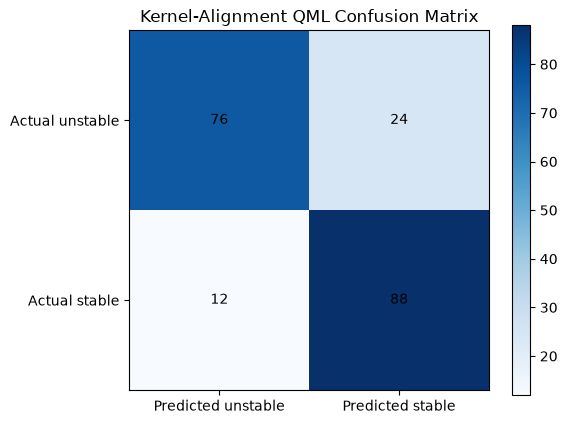

In [19]:
alignment_qml_confusion_matrix = confusion_matrix(
    alignment_true_labels,
    alignment_qml_predicted_labels,
    labels=[0, 1],
)
alignment_confusion_dataframe = pd.DataFrame(
    alignment_qml_confusion_matrix,
    index=["actual_unstable", "actual_stable"],
    columns=["predicted_unstable", "predicted_stable"],
)
display(alignment_confusion_dataframe)

plt.figure(figsize=(5.8, 4.8))
plt.imshow(alignment_qml_confusion_matrix, cmap="Blues")
plt.title("Kernel-Alignment QML Confusion Matrix")
plt.xticks([0, 1], ["Predicted unstable", "Predicted stable"])
plt.yticks([0, 1], ["Actual unstable", "Actual stable"])
for row_index in range(2):
    for column_index in range(2):
        cell_value = alignment_qml_confusion_matrix[row_index, column_index]
        plt.text(column_index, row_index, cell_value, ha="center", va="center")
plt.colorbar()
plt.show()

In [20]:
improved_qml_alignment_predictions_dataframe = read_project_data("improved qml alignment predictions.csv")

alignment_sample_predictions_dataframe = improved_qml_alignment_predictions_dataframe[
    [
        "material_id",
        "formula",
        "target_is_stable",
        "alignment_qml_predicted_label",
        "alignment_qml_stable_probability",
    ]
].head(10)
display(alignment_sample_predictions_dataframe)


,material_id,formula,target_is_stable,alignment_qml_predicted_label,alignment_qml_stable_probability
0,mp-861915,LiDy2Ir,1,1,0.845188
1,mp-1191394,Li8Nd7Ge10,0,1,0.856185
2,mp-759724,Li3MnF7,0,1,0.703930
3,mp-37480,LiSbSe2,0,1,0.862632
4,mp-3203193,LiV(CuS2)2,1,1,0.873197
5,mp-3203521,BaSr2(LiSn2)4,1,1,0.861833
6,mp-1212343,Li22(Cu3Si2)7,1,1,0.823178
7,mp-1185354,LiGd2Os,1,1,0.838931
8,mp-776176,Li4Ti3V3(CuO8)2,0,0,0.130006
9,mp-758945,Li5CuHO4,0,0,0.129834


In [21]:
best_qml_repeated_split_results_dataframe = read_project_data("best qml repeated split results.csv")

repeated_split_summary_rows = []
repeated_split_metric_columns = [
    "accuracy",
    "stable_precision",
    "stable_recall",
    "stable_f1",
]

for metric_name in repeated_split_metric_columns:
    metric_values = best_qml_repeated_split_results_dataframe[metric_name]
    mean_value = metric_values.mean()
    standard_deviation_value = metric_values.std(ddof=1)
    minimum_value = metric_values.min()
    maximum_value = metric_values.max()

    repeated_split_summary_rows.append(
        {
            "metric": metric_name,
            "mean": mean_value,
            "standard_deviation": standard_deviation_value,
            "minimum": minimum_value,
            "maximum": maximum_value,
        }
    )

repeated_split_summary_dataframe = pd.DataFrame(repeated_split_summary_rows).round(4)
display(repeated_split_summary_dataframe)


,metric,mean,standard_deviation,minimum,maximum
0,accuracy,0.8550,0.0220,0.8150,0.8900
1,stable_precision,0.8389,0.0266,0.8053,0.8854
2,stable_recall,0.8800,0.0394,0.8200,0.9600
3,stable_f1,0.8583,0.0223,0.8159,0.8972


In [22]:
qml_vs_logistic_summary_dataframe = read_project_data("qml vs logistic repeated split summary.csv")

def get_mean_score(model_name, metric_name):
    model_rows = qml_vs_logistic_summary_dataframe[
        qml_vs_logistic_summary_dataframe["model"] == model_name
    ]
    metric_rows = model_rows[model_rows["metric"] == metric_name]
    mean_score = metric_rows["mean"].iloc[0]
    return mean_score

qml_vs_logistic_comparison_rows = []
metric_names = ["accuracy", "stable_precision", "stable_recall", "stable_f1"]

for metric_name in metric_names:
    qml_mean = get_mean_score("QML kernel classifier", metric_name)
    logistic_mean = get_mean_score("Logistic Regression", metric_name)
    difference = qml_mean - logistic_mean

    if difference > 0:
        winner = "QML"
    elif difference < 0:
        winner = "Logistic Regression"
    else:
        winner = "Tie"

    qml_vs_logistic_comparison_rows.append(
        {
            "metric": metric_name,
            "qml_mean": round(qml_mean, 4),
            "logistic_mean": round(logistic_mean, 4),
            "qml_minus_logistic": round(difference, 4),
            "winner": winner,
        }
    )

qml_vs_logistic_comparison_dataframe = pd.DataFrame(qml_vs_logistic_comparison_rows)
display(qml_vs_logistic_comparison_dataframe)


,metric,qml_mean,logistic_mean,qml_minus_logistic,winner
0,accuracy,0.8550,0.8410,0.0140,QML
1,stable_precision,0.8389,0.8144,0.0245,QML
2,stable_recall,0.8800,0.8840,-0.0040,Logistic Regression
3,stable_f1,0.8583,0.8473,0.0110,QML


# Presentation Conclusion

**What we achieved**

- Built a complete lithium battery material pipeline.
- Created India-focused material scoring and final shortlist.
- Added QML-primary DSS recommendation rankings for exact compound formulas.
- Trained XGBoost as the strong present-day classical benchmark.
- Prepared a balanced QML-ready dataset.
- Trained a first Qiskit Statevector quantum-kernel classifier as the quantum-future
  experiment.
- Tuned QML hyperparameters using 4-fold cross-validation.
- Added exhaustive QML feature-combination tuning with 8,388 saved
  configurations.
- Added a separate improved-QML section using feature importance, PCA, and an
  entangled-kernel search.
- Added a threshold experiment for the improved-QML stable probability.
- Added a kernel-alignment experiment for quantum-aware feature selection.
- Validated the best QML setup across 10 random train/test splits.
- Compared best QML with Logistic Regression on the same repeated splits.
- Added a gate-level visual diagram for the best 4-qubit QML feature map.

**Main model result**

- XGBoost full-project accuracy: **0.9091**
- XGBoost regressor MAE: **0.1005**
- QML accuracy on QML-ready test split: **0.8100**
- Tuned QML accuracy on QML-ready test split: **0.8200**
- Tuned QML stable F1 on QML-ready test split: **0.8269**
- Improved QML separate-section accuracy: **0.8200**
- Improved QML separate-section stable F1: **0.8235**
- Improved QML threshold-tuned accuracy: **0.8300**
- Improved QML threshold-tuned stable F1: **0.8381**
- Improved QML kernel-alignment accuracy: **0.8200**
- Improved QML kernel-alignment stable F1: **0.8302**
- Repeated-split mean accuracy: **0.8550**
- Repeated-split mean stable F1: **0.8583**
- QML vs Logistic mean accuracy: **0.8550 vs 0.8410**
- QML vs Logistic mean stable F1: **0.8583 vs 0.8473**
- Same-data XGBoost accuracy: **0.8300**

**Safe interpretation**

XGBoost is stronger on the full tabular benchmark, but the final DSS is
quantum-led. QML gives the first recommendation signal and XGBoost is used as a
corrective backup when QML is uncertain or when the models disagree. The safe
student-level point is that quantum feature spaces are future-facing for
materials discovery, while classical ML can still act as a practical safety
check today.
